# Requirements

To run this notebook, you will need:
- Python 3.12 and the following dependencies:
    - amplpy
    - cplex
    - notebook/ipykernel
- AMPL + CPLEX

In [1]:
from IPython.core.pylabtools import figsize

%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
from matplotlib import pyplot as plt

from lower_bounds import (
    arcs_as_dataframe,
    export_arcs_to_csv,
    find_gomory_cut,
    sec_identification,
    find_2match,
    solve_relaxation,
    solve_ilp,
    clear_cuts,
    add_cut,
    is_circuit,
    connected_components,
    paint_graph,
)

In [3]:
clear_cuts()
summary_data = []

In [4]:
def summary_entry(name, arcs, cost) -> list:
    return [
        name,
        cost,
        sum(not v.is_integer() for v in arcs.values()),
        connected_components(arcs),
        is_circuit(arcs),
    ]

## a) Linear relaxation

In [5]:
lr_arcs, lr_cost = solve_relaxation()
lr_df = arcs_as_dataframe(lr_arcs)
export_arcs_to_csv(lr_arcs, "./data/relaxation.csv")
summary_data.append(summary_entry("Base Relaxation", lr_arcs, lr_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6043
33 simplex iterations


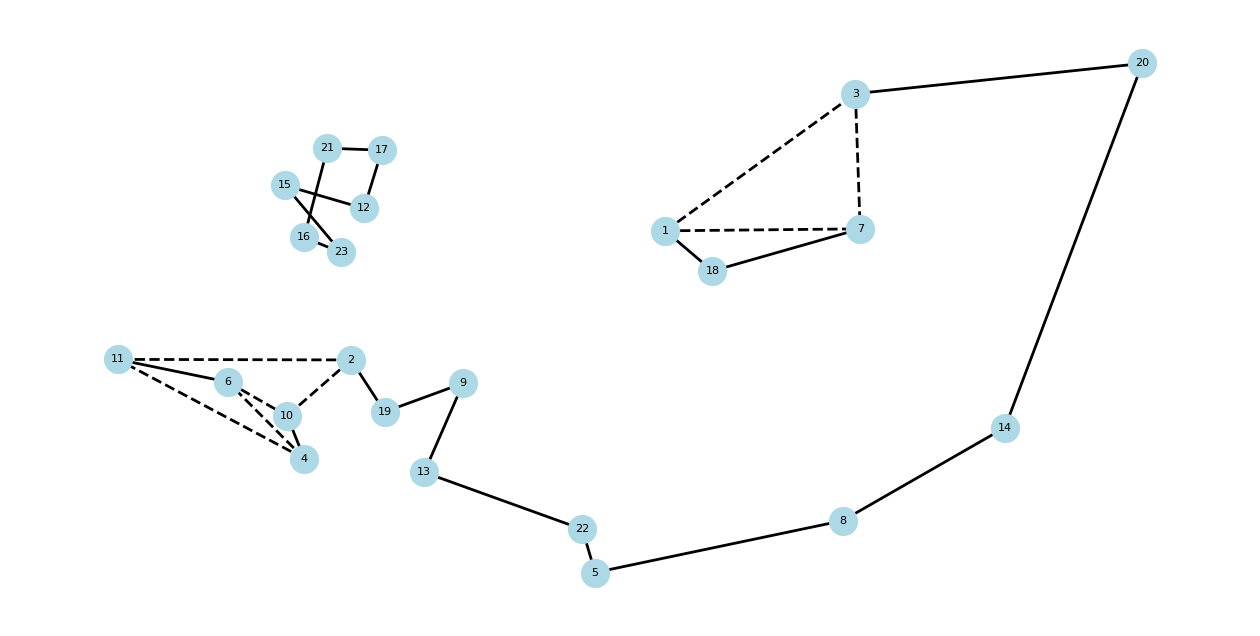

In [11]:
lr_fig, lr_axes = plt.subplots(1, 1, figsize=(16, 8))
paint_graph(lr_arcs, axes=lr_axes)
lr_fig.savefig("images/relaxation.png", dpi=400)

## b) SEC

In [12]:
sec_cut = sec_identification(lr_arcs)
add_cut(sec_cut, "SEC")

Merging node 1 ({1}) and node 18 ({18}) into node A
Subtour found between nodes {1, 18, 7}
x[1, 7] + x[1, 18] + x[7, 18] = 2.5 !<= 2


In [13]:
sec_arcs, sec_cost = solve_relaxation()
sec_df = arcs_as_dataframe(sec_arcs)
export_arcs_to_csv(sec_arcs, "./data/sec_1.csv")
summary_data.append(summary_entry("SEC 1", sec_arcs, sec_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6146.5
38 simplex iterations


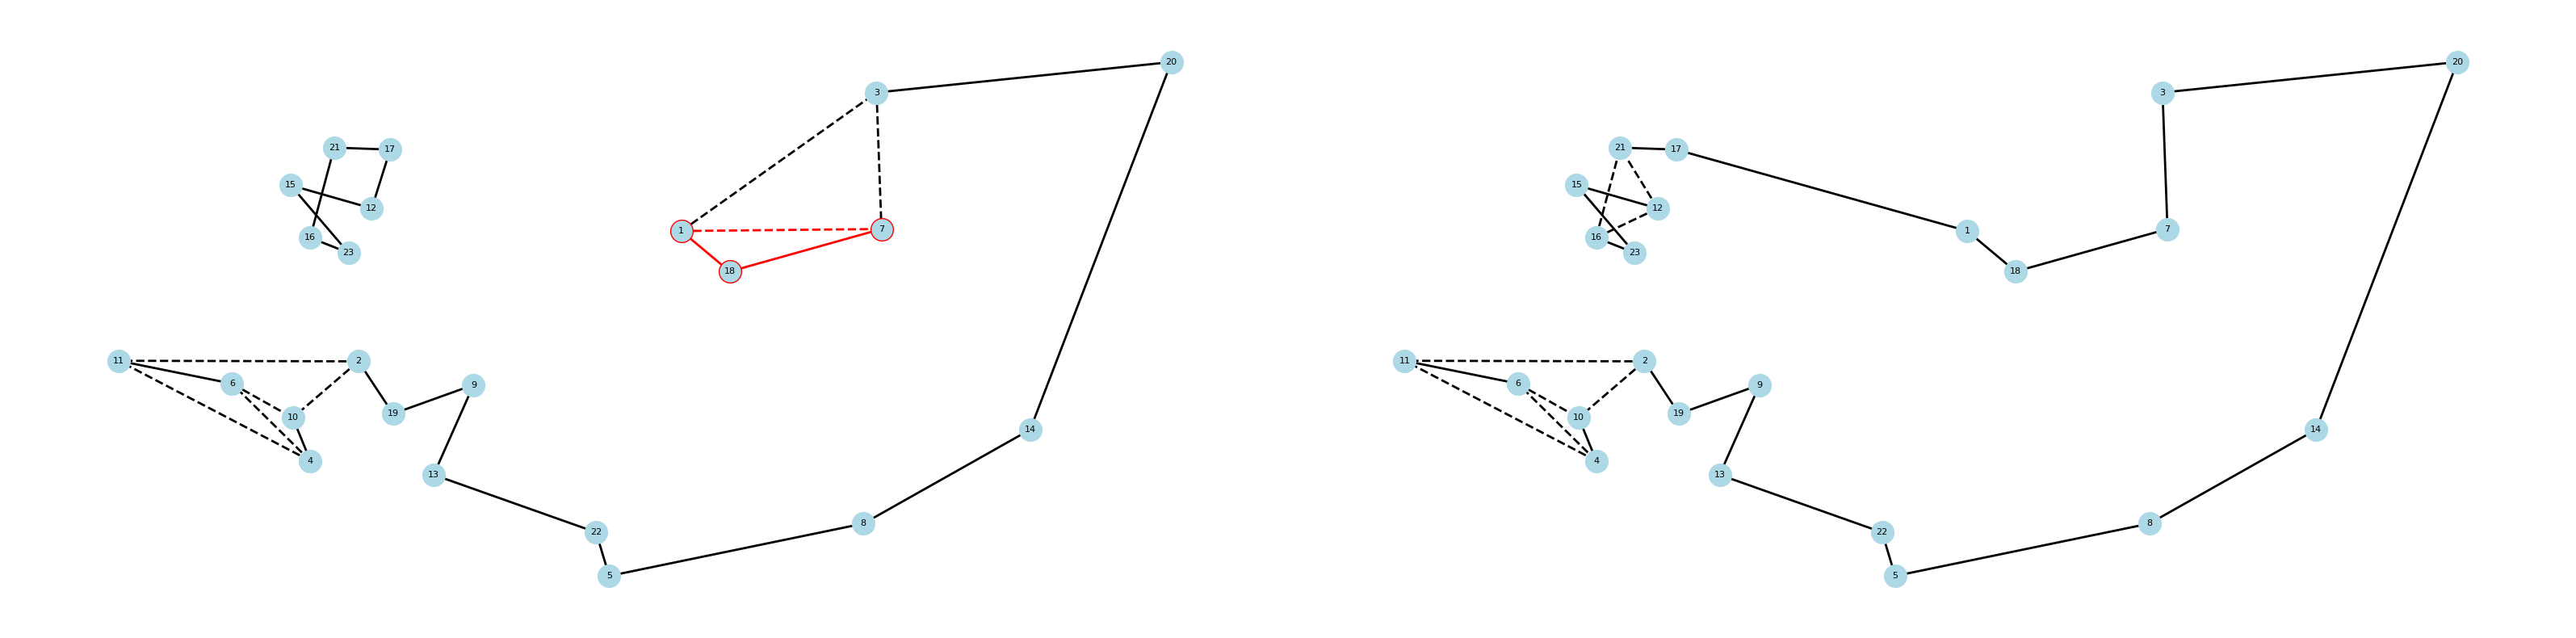

In [47]:
sec_fig, sec_axes = plt.subplots(1, 2, figsize=(32, 8))
paint_graph(
    lr_arcs,
    axes=sec_axes[0],
    personalized_arcs={
        (1, 7): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(1, 7)].is_integer() else "dashed",
        },
        (1, 18): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(1, 18)].is_integer() else "dashed",
        },
        (7, 18): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(7, 18)].is_integer() else "dashed",
        },
    },
    personalized_nodes={
        1: {"node_color": "lightblue", "edgecolors": "red"},
        7: {"node_color": "lightblue", "edgecolors": "red"},
        18: {"node_color": "lightblue", "edgecolors": "red"},
    }
)
paint_graph(sec_arcs, axes=sec_axes[1])
plt.tight_layout()
sec_fig.savefig("images/sec_1.png", dpi=400)

In [21]:
sec_cut_2 = sec_identification(sec_arcs)
add_cut(sec_cut_2, "SEC")

Merging node 1 ({1}) and node 17 ({17}) into node A
Merging node 18 ({18}) and node A ({1, 17}) into node B
Merging node 7 ({7}) and node B ({1, 18, 17}) into node C
Merging node 3 ({3}) and node C ({1, 18, 17, 7}) into node D
Merging node 20 ({20}) and node D ({1, 18, 3, 17, 7}) into node E
Merging node 14 ({14}) and node E ({1, 18, 3, 20, 17, 7}) into node F
Merging node 8 ({8}) and node F ({1, 18, 3, 20, 17, 7, 14}) into node G
Merging node 5 ({5}) and node G ({1, 3, 7, 8, 14, 17, 18, 20}) into node H
Merging node 21 ({21}) and node H ({1, 3, 5, 7, 8, 14, 17, 18, 20}) into node I
Merging node 22 ({22}) and node I ({1, 3, 5, 7, 8, 14, 17, 18, 20, 21}) into node J
Merging node 13 ({13}) and node J ({1, 3, 5, 7, 8, 14, 17, 18, 20, 21, 22}) into node K
Merging node 9 ({9}) and node K ({1, 3, 5, 7, 8, 13, 14, 17, 18, 20, 21, 22}) into node L
Merging node 19 ({19}) and node L ({1, 3, 5, 7, 8, 9, 13, 14, 17, 18, 20, 21, 22}) into node M
Merging node 2 ({2}) and node M ({1, 3, 5, 7, 8, 9, 1

In [22]:
sec_2_arcs, sec_2_cost = solve_relaxation()
sec_2_df = arcs_as_dataframe(sec_2_arcs)
export_arcs_to_csv(sec_2_arcs, "./data/sec_2.csv")
summary_data.append(summary_entry("SEC 2", sec_2_arcs, sec_2_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6147
37 simplex iterations


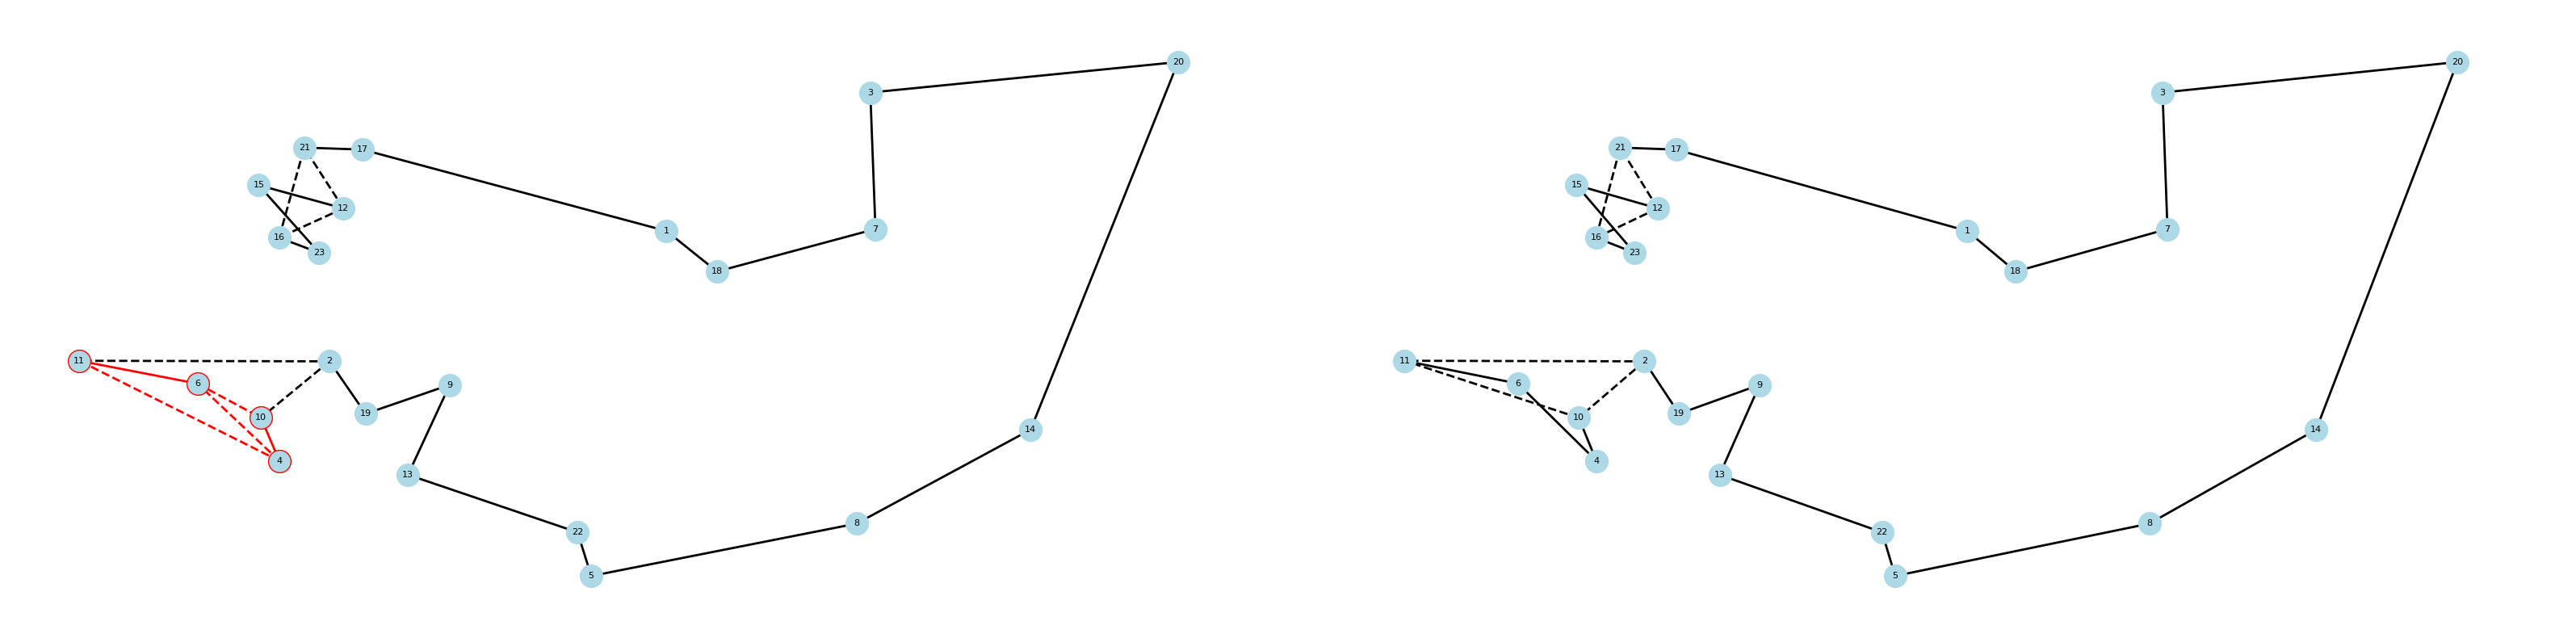

In [46]:
sec_2_fig, sec_2_axes = plt.subplots(1, 2, figsize=(32, 8))
paint_graph(
    sec_arcs,
    axes=sec_2_axes[0],
    personalized_arcs={
        (4, 6): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(4, 6)].is_integer() else "dashed",
        },
        (4, 10): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(4, 10)].is_integer() else "dashed",
        },
        (4, 11): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(4, 11)].is_integer() else "dashed",
        },
        (6, 10): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(6, 10)].is_integer() else "dashed",
        },
        (6, 11): {
            "edge_color": "red",
            "style": "solid" if lr_arcs[(6, 11)].is_integer() else "dashed",
        },
    },
    personalized_nodes={
        4: {"node_color": "lightblue", "edgecolors": "red"},
        6: {"node_color": "lightblue", "edgecolors": "red"},
        10: {"node_color": "lightblue", "edgecolors": "red"},
        11: {"node_color": "lightblue", "edgecolors": "red"},
    }
)
paint_graph(sec_2_arcs, axes=sec_2_axes[1])
plt.tight_layout()

sec_2_fig.savefig("images/sec_2.png", dpi=400)

## c) 2-matching Cut

In [31]:
match_cut = find_2match(sec_2_arcs)
add_cut(match_cut, "2Matching")

(x[2, 10] + x[2, 11] + x[10, 11]) + x[2, 19] + x[4, 10] + x[6, 11] = 4.5 !<= 4


In [32]:
match_arcs, match_cost = solve_relaxation()
export_arcs_to_csv(match_arcs, "./data/match_1.csv")
summary_data.append(summary_entry("2-Matching Cut 1", match_arcs, match_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6148.5
37 simplex iterations


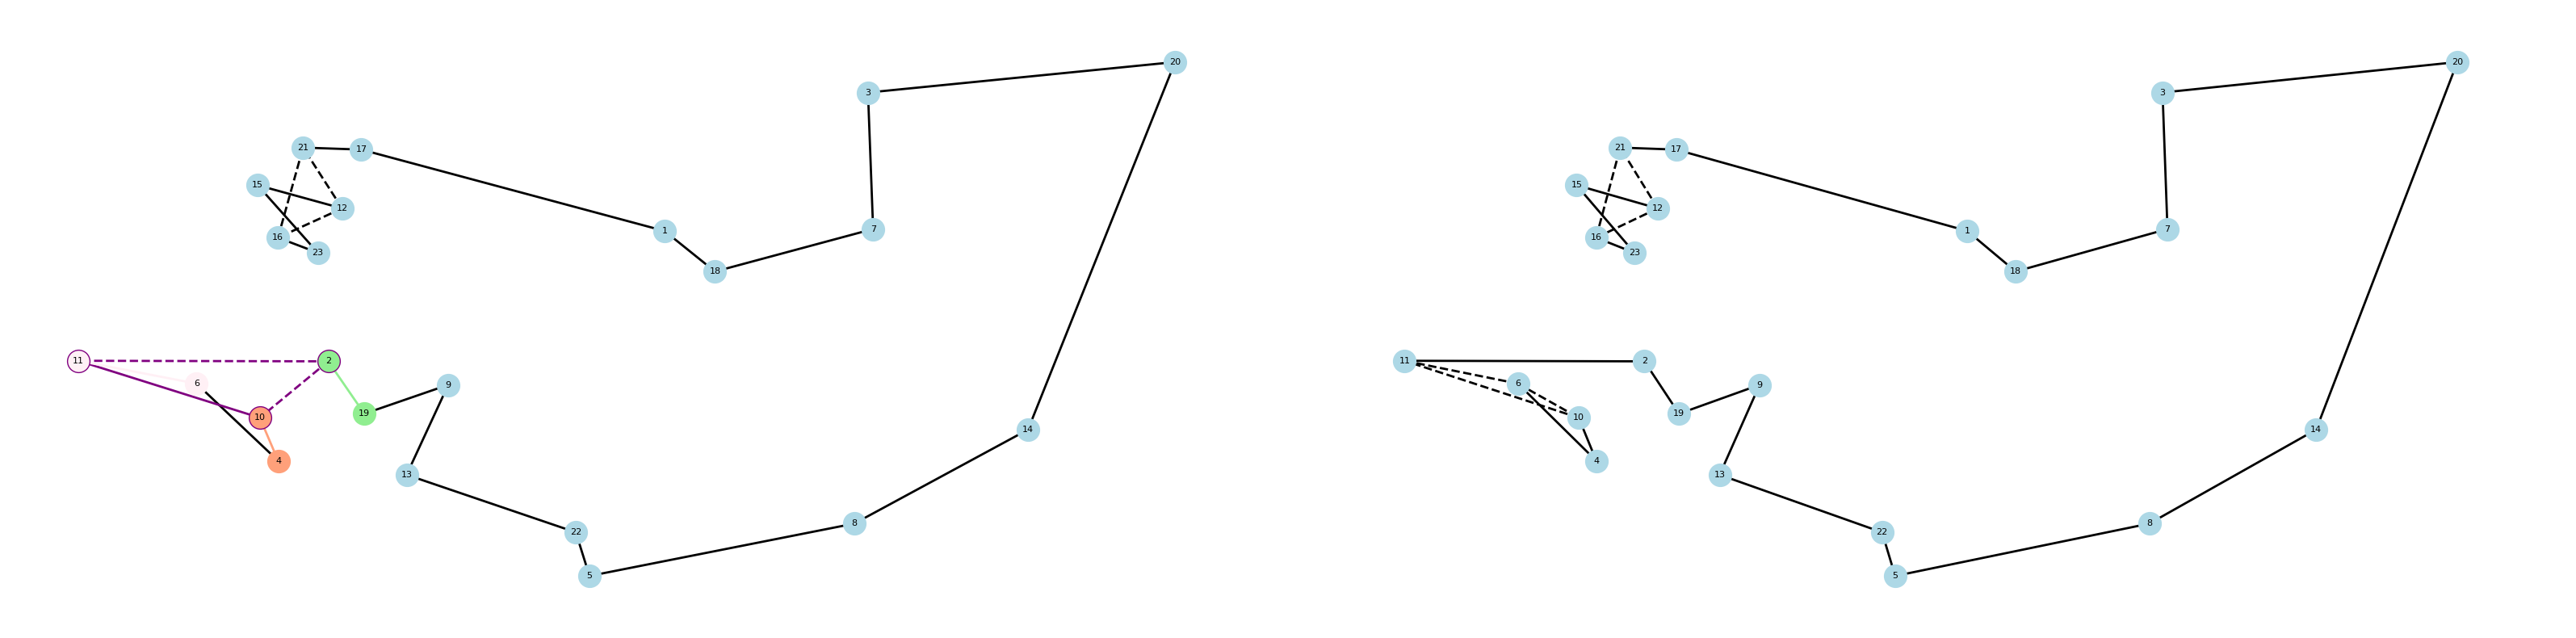

In [48]:
match_fig, match_axes = plt.subplots(1, 2, figsize=(32, 8))
paint_graph(
    sec_2_arcs,
    axes=match_axes[0],
    personalized_arcs={
        (2, 10): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(2, 10)].is_integer() else "dashed",
        },
        (2, 11): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(2, 11)].is_integer() else "dashed",
        },
        (10, 11): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(10, 11)].is_integer() else "dashed",
        },
        (6, 11): {
            "edge_color": "lavenderblush",
            "style": "solid" if lr_arcs[(6, 11)].is_integer() else "dashed",
        },
        (2, 19): {
            "edge_color": "lightgreen",
            "style": "solid" if lr_arcs[(2, 19)].is_integer() else "dashed",
        },
        (4, 10): {
            "edge_color": "lightsalmon",
            "style": "solid" if lr_arcs[(4, 10)].is_integer() else "dashed",
        },
    },
    personalized_nodes={
        2: {"node_color": "lightgreen", "edgecolors": "purple"},
        10: {"node_color": "lightsalmon", "edgecolors": "purple"},
        11: {"node_color": "lavenderblush", "edgecolors": "purple"},
        19: {"node_color": "lightgreen"},
        4: {"node_color": "lightsalmon"},
        6: {"node_color": "lavenderblush"},
    }
)
paint_graph(match_arcs, axes=match_axes[1])
plt.tight_layout()

match_fig.savefig("images/match_1.png", dpi=400)

In [43]:
match_cut_2 = find_2match(match_arcs)
add_cut(match_cut_2, "2Matching")

(x[12, 16] + x[12, 21] + x[16, 21]) + x[12, 15] + x[16, 23] + x[17, 21] = 4.5 !<= 4


In [44]:
match_2_arcs, match_2_cost = solve_relaxation()
export_arcs_to_csv(match_2_arcs, "./data/match_2.csv")
summary_data.append(summary_entry("2-Matching Cut 2", match_2_arcs, match_2_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6149.5
37 simplex iterations


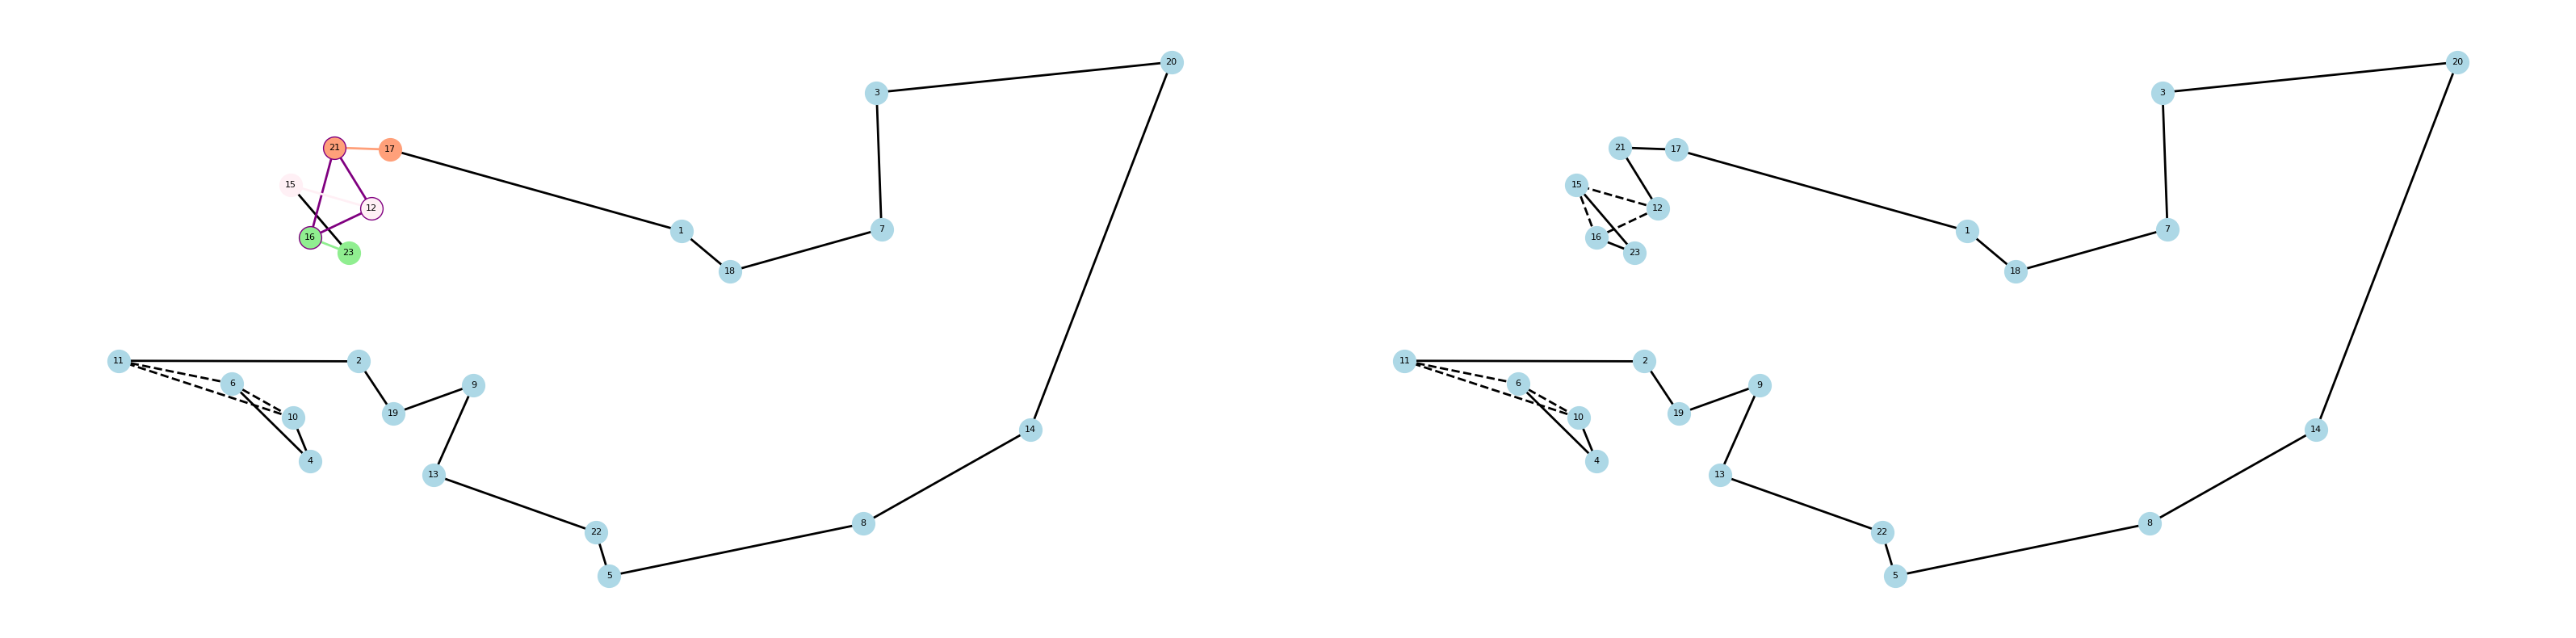

In [49]:
match_2_fig, match_2_axes = plt.subplots(1, 2, figsize=(32, 8))
paint_graph(
    match_arcs,
    axes=match_2_axes[0],
    personalized_arcs={
        (12, 16): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(12, 16)].is_integer() else "dashed",
        },
        (12, 21): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(12, 21)].is_integer() else "dashed",
        },
        (16, 21): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(16, 21)].is_integer() else "dashed",
        },
        (12, 15): {
            "edge_color": "lavenderblush",
            "style": "solid" if lr_arcs[(12, 15)].is_integer() else "dashed",
        },
        (16, 23): {
            "edge_color": "lightgreen",
            "style": "solid" if lr_arcs[(16, 23)].is_integer() else "dashed",
        },
        (17, 21): {
            "edge_color": "lightsalmon",
            "style": "solid" if lr_arcs[(17, 21)].is_integer() else "dashed",
        },
    },
    personalized_nodes={
        12: {"node_color": "lavenderblush", "edgecolors": "purple"},
        16: {"node_color": "lightgreen", "edgecolors": "purple"},
        21: {"node_color": "lightsalmon", "edgecolors": "purple"},
        15: {"node_color": "lavenderblush"},
        23: {"node_color": "lightgreen"},
        17: {"node_color": "lightsalmon"},
    }
)
paint_graph(match_2_arcs, axes=match_2_axes[1])
plt.tight_layout()

match_2_fig.savefig("images/match_2.png", dpi=400)

## d) Gomory Cut

In [50]:
gomory_cuts = find_gomory_cut()
for cut in gomory_cuts:
    add_cut(cut, "Gomory")

[ERROR] 
	Error executing "write" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


Reading AMPL model
Exporting AMPL model
Loading model in CPLEX

Selected objective sense:  MINIMIZE
Selected objective  name:  R0028
Selected RHS        name:  B
Selected bound      name:  BOUND
Version identifier: 22.1.2.0 | 2024-12-09 | 8bd2200c8
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
No LP presolve or aggregator reductions.
Presolve time = 0.00 sec. (0.15 ticks)
Initializing dual steep norms . . .

Iteration log . . .
Iteration:     1   Dual objective     =           507.000000
x[1, 17],1.0
x[4, 11],0.0
x[6, 11],0.5
x[12, 15],0.5
x[1, 7],0.0
x[2, 19],1.0
x[3, 7],1.0
x[10, 11],0.5
x[5, 8],1.0
x[4, 6],1.0
x[7, 20],0.0
x[2, 9],0.0
x[9, 19],1.0
x[6, 10],0.5
x[2, 11],1.0
x[12, 16],0.5
x[7, 14],0.0
x[5, 14],0.0
x[15, 23],1.0
x[15, 16],0.5
x[12, 17],0.0
x[7, 18],1.0
x[13, 19],0.0
x[1, 3],0.0
x[12, 21],1.0
x[13, 22],1.0
x[16, 21],0.0
Ignoring integer basic variable
Ignoring integer basic variable
Selected variable x[6, 11] C0105 (tableau index 2) with va

In [51]:
gomory_arcs, gomory_cost = solve_relaxation()
export_arcs_to_csv(gomory_arcs, "./data/gomory.csv")
summary_data.append(summary_entry("Gomory Cuts", gomory_arcs, gomory_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6363
39 simplex iterations


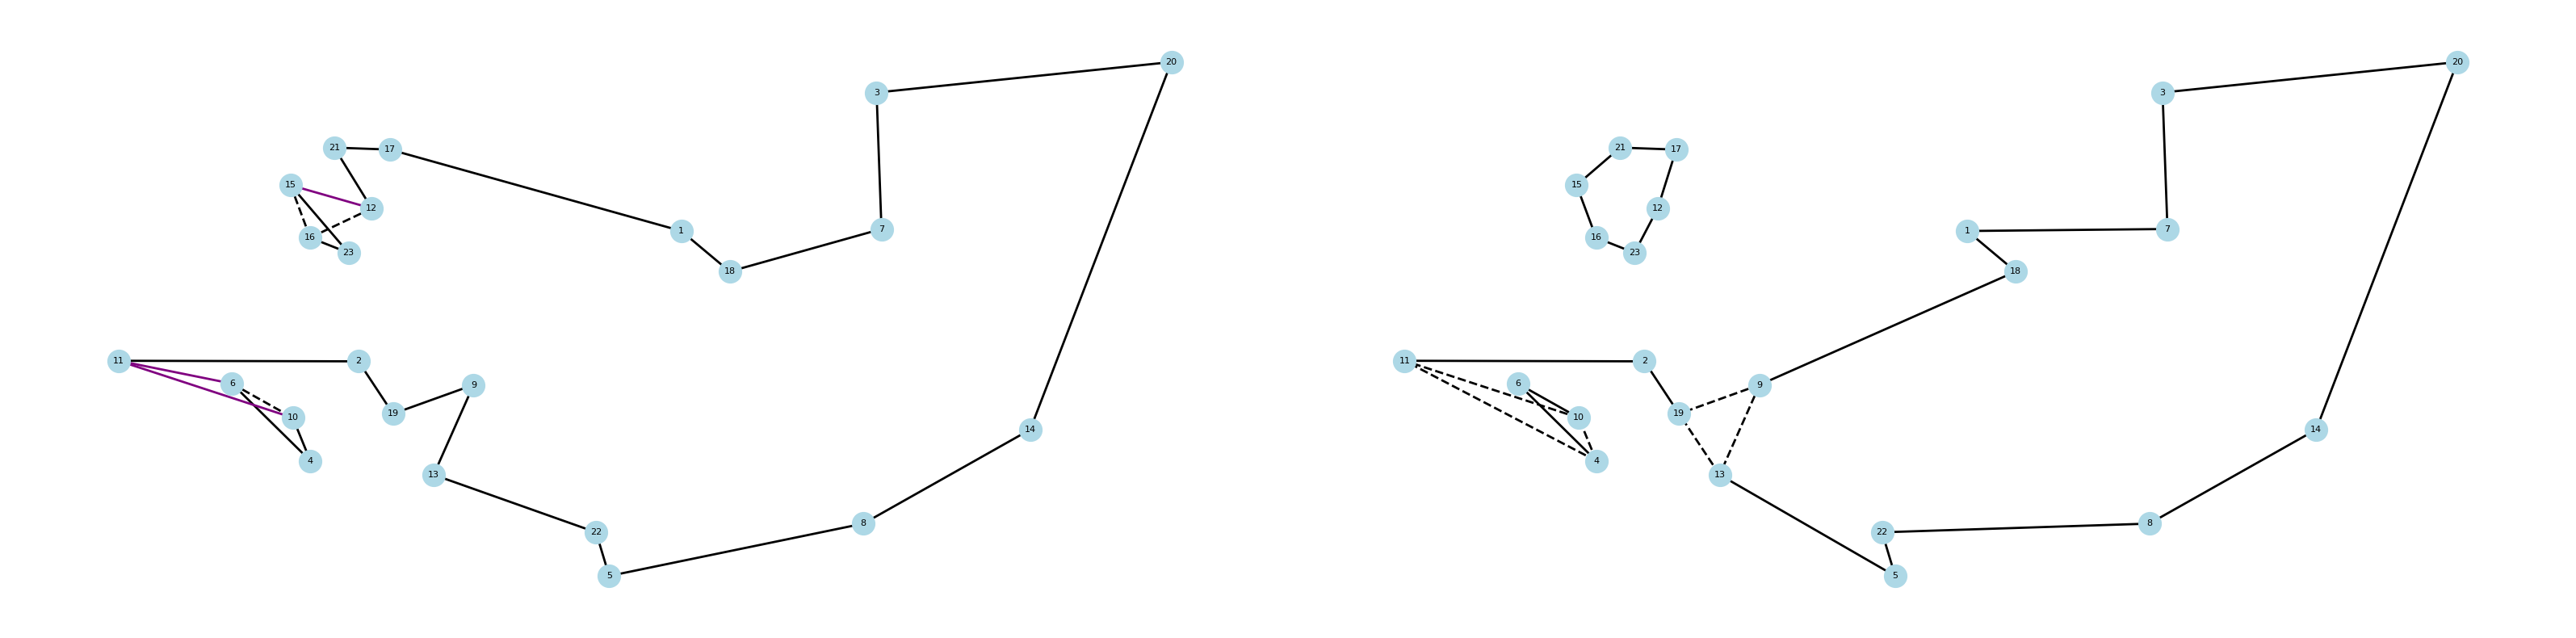

In [53]:
gomory_fig, gomory_axes = plt.subplots(1, 2, figsize=(32, 8))
paint_graph(
    match_2_arcs,
    axes=gomory_axes[0],
    personalized_arcs={
        (6, 11): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(6, 11)].is_integer() else "dashed",
        },
        (12, 15): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(12, 15)].is_integer() else "dashed",
        },
        (10, 11): {
            "edge_color": "purple",
            "style": "solid" if lr_arcs[(10, 11)].is_integer() else "dashed",
        },
    },
)
paint_graph(gomory_arcs, axes=gomory_axes[1])
plt.tight_layout()

gomory_fig.savefig("images/gomory.png", dpi=400)

## e) Branch-and-Bound

In [55]:
integer_arcs, integer_cost = solve_ilp()
export_arcs_to_csv(integer_arcs, "./data/ilp.csv")
summary_data.append(summary_entry("Branch & Bound", integer_arcs, integer_cost))

[ERROR] 
	Error executing "solve" command:
	error processing param c:
		276 invalid subscripts discarded:
		c[1,1]
		c[2,1]
		c[2,2]
		and 273 more.


CPLEX 22.1.2: CPLEX 22.1.2: optimal solution; objective 6387
49 simplex iterations


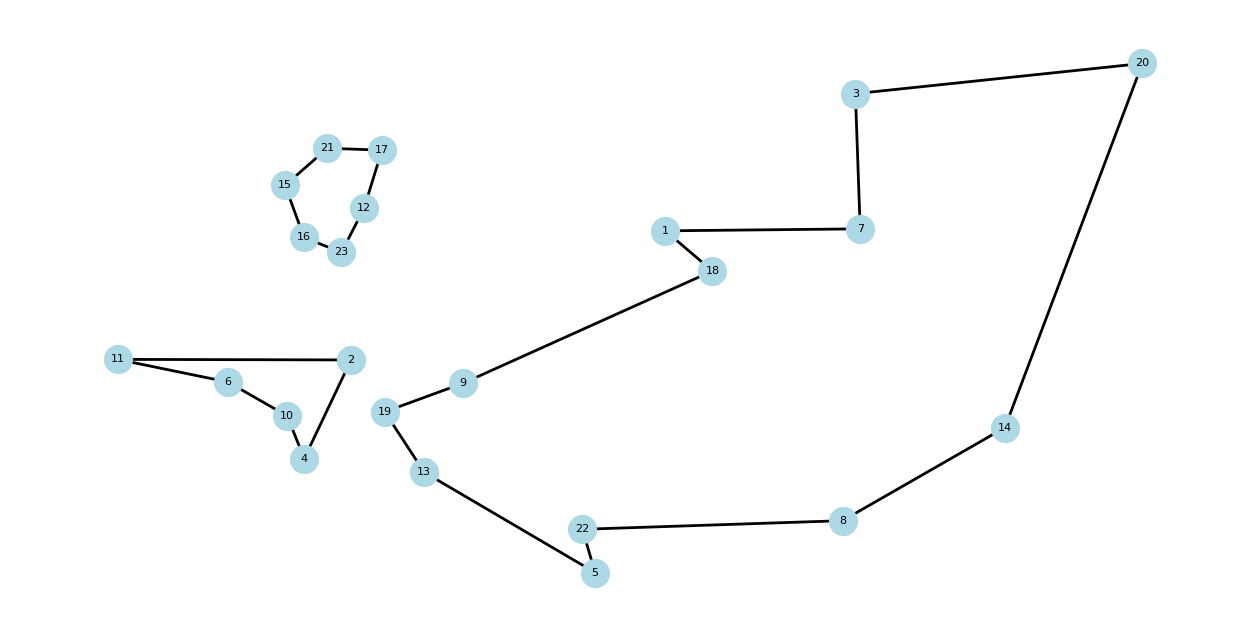

In [56]:
integer_fig, integer_axes = plt.subplots(1, 1, figsize=(16, 8))
paint_graph(integer_arcs, axes=integer_axes)
integer_fig.savefig("images/integer.png", dpi=400)

## Summary

In [ ]:
df = pd.DataFrame(
    data=summary_data,
    columns=["Name", "Cost", "# Fractional arcs", "# Connected Components", "Circuit"],
)
df.to_csv("./data/summary.csv", index=False)
df

# Tests

In [ ]:
arcs = {
    (1, 2): 1,
    (1, 3): 5 / 12,
    (1, 4): 5 / 12,
    (1, 5): 1 / 6,
    (2, 3): 5 / 12,
    (2, 4): 5 / 12,
    (2, 6): 1 / 6,
    (3, 4): 1,
    (3, 7): 1 / 6,
    (4, 8): 1 / 6,
    (5, 6): 1,
    (5, 7): 5 / 12,
    (5, 8): 5 / 12,
    (6, 7): 5 / 12,
    (6, 8): 5 / 12,
    (7, 8): 1,
}

In [ ]:
sec_identification(arcs)

In [ ]:
arcs = {
    (1, 2): 1 / 2,
    (1, 3): 1 / 2,
    (1, 4): 1,
    (2, 3): 1 / 2,
    (2, 5): 1,
    (3, 6): 1,
    (4, 5): 1 / 2,
    (4, 6): 1 / 2,
    (5, 6): 1 / 2,
}

In [ ]:
find_2match(arcs)

In [ ]:
find_gomory_cut(arcs)

In [ ]:
for i in range(1, 24):
    for j in range(i + 1, 24):
        print(f"({i}, {j})", end=" ")
    print("")

In [ ]:
import json

with open("lower_bounds/data.json", "r", encoding="utf8") as f:
    d = json.load(f)

In [ ]:
locations = [(node["lon"], node["lat"]) for node in d["nodes"]]
with open("lower_bounds/locations.json", "w", encoding="utf8") as f:
    json.dump(locations, f)